<a href="https://colab.research.google.com/github/MakandaukoJD/DataAnalysis/blob/main/PCR_Log_Data_Clean_up.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import the file to Colab Space

In [2]:
from google.colab import files
uploaded = files.upload()

Saving PCR_Log2.xlsx to PCR_Log2.xlsx


Add Library First
1. to read excel
2. to manipulate data
3. Visualise

In [32]:
library(readxl)
library(dplyr)
library(ggplot2)

In [33]:
data <- read_excel("PCR_Log2.xlsx")

In [34]:
head(data)

ID,Day0,Day14,Day28,Day35,Day42,Day63,B/O,Unsch,Monthly,Delivery mother,Delivery baby,Placenta
<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
IP228,NA,NA,Collected,Collected,Collected,Collected,NA,NA,NA,NA,NA,NA
IP091,NA,NA,Collected,NA,NA,Collected,Collected,NA,NA,Collected,NA,Collected Damaged
IP180,NA,Collected,Collected,Collected(damaged),Collected,Collected,NA,NA,NA,NA,NA,NA
IP181,NA,Collected,Collected,Collected,Collected(damaged),Collected,NA,NA,NA,NA,NA,NA
IP171,NA,Collected,Collected,Collected,Collected,Collected,NA,NA,NA,NA,NA,NA
IP072,NA,Collected,NA,NA,Collected,Collected,NA,NA,NA,NA,NA,NA


Inspect the Data

In [35]:
str(data)

tibble [424 × 13] (S3: tbl_df/tbl/data.frame)
 $ ID             : chr [1:424] "IP228" "IP091" "IP180" "IP181" ...
 $ Day0           : logi [1:424] NA NA NA NA NA NA ...
 $ Day14          : chr [1:424] NA NA "Collected" "Collected" ...
 $ Day28          : chr [1:424] "Collected" "Collected" "Collected" "Collected" ...
 $ Day35          : chr [1:424] "Collected" NA "Collected(damaged)" "Collected" ...
 $ Day42          : chr [1:424] "Collected" NA "Collected" "Collected(damaged)" ...
 $ Day63          : chr [1:424] "Collected" "Collected" "Collected" "Collected" ...
 $ B/O            : chr [1:424] NA "Collected" NA NA ...
 $ Unsch          : chr [1:424] NA NA NA NA ...
 $ Monthly        : chr [1:424] NA NA NA NA ...
 $ Delivery mother: chr [1:424] NA "Collected" NA NA ...
 $ Delivery baby  : chr [1:424] NA NA NA NA ...
 $ Placenta       : chr [1:424] NA "Collected Damaged" NA NA ...


In [36]:
id_vector <- data$ID

In [37]:
head(id_vector)

[1] "IP228" "IP091" "IP180" "IP181" "IP171" "IP072"

In [38]:
id_counts <- table(id_vector)

In [39]:
head(id_counts)

id_vector
IP 237  IP001  IP003  IP006  IP007  IP008 
     1      1      1      1      1      1 

In [63]:
id_mode <- names(id_counts)[id_counts > 1]

In [65]:
head(id_mode)

[1] "IP013" "IP045" "IP050" "IP051" "IP053" "IP089"

In [66]:
id_mode

[1] "IP013" "IP045" "IP050" "IP051" "IP053" "IP089" "IP106" "IP123" "IP124"
[10] "IP131" "IP142" "IP148" "IP158" "IP185" "IP189" "IP195" "IP200" "IP226"
[19] "IP232" "IP268" "IP277" "IP282" "IP327" "IP337" "IP340" "IP349" "IP366"
[28] "IP368" "IP383" "IP384"

In [67]:
id_counts

id_vector
IP 237  IP001  IP003  IP006  IP007  IP008  IP009  IP011 IP0129  IP013  IP014 
     1      1      1      1      1      1      1      1      1      2      1 
 IP015  IP016  IP017  IP018 IP0185  IP019  IP020  IP021  IP022  IP023  IP024 
     1      1      1      1      1      1      1      1      1      1      1 
 IP025  IP026  IP027  IP028  IP029  IP030  IP031  IP032  IP033  IP034  IP035 
     1      1      1      1      1      1      1      1      1      1      1 
 IP036  IP037  IP039  IP040  IP041  IP043  IP044  IP045  IP046  IP047  IP048 
     1      1      1      1      1      1      1      2      1      1      1 
 IP049  IP050  IP051  IP052  IP053  IP054  IP055  IP056  IP057  IP058  IP059 
     1      2      2      1      2      1      1      1      1      1      1 
 IP064  IP066  IP067  IP068  IP069  IP071  IP072  IP073  IP075  IP076  IP077 
     1      1      1      1      1      1      1      1      1      1      1 
 IP079  IP080  IP082  IP083  IP084  IP085  IP087  IP08

Turn what you want to visualise into a data frame

In [68]:
idcounts_df <- as.data.frame(id_counts)

Rename the columns (The ---> direction)

In [70]:
colnames(idcounts_df) <- c("ID", "Count")

Plot

# Create the bar graph
ggplot(data, aes(x = Category, y = Value)) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = "Basic Bar Graph", x = "Category", y = "Value") +
  theme_minimal()

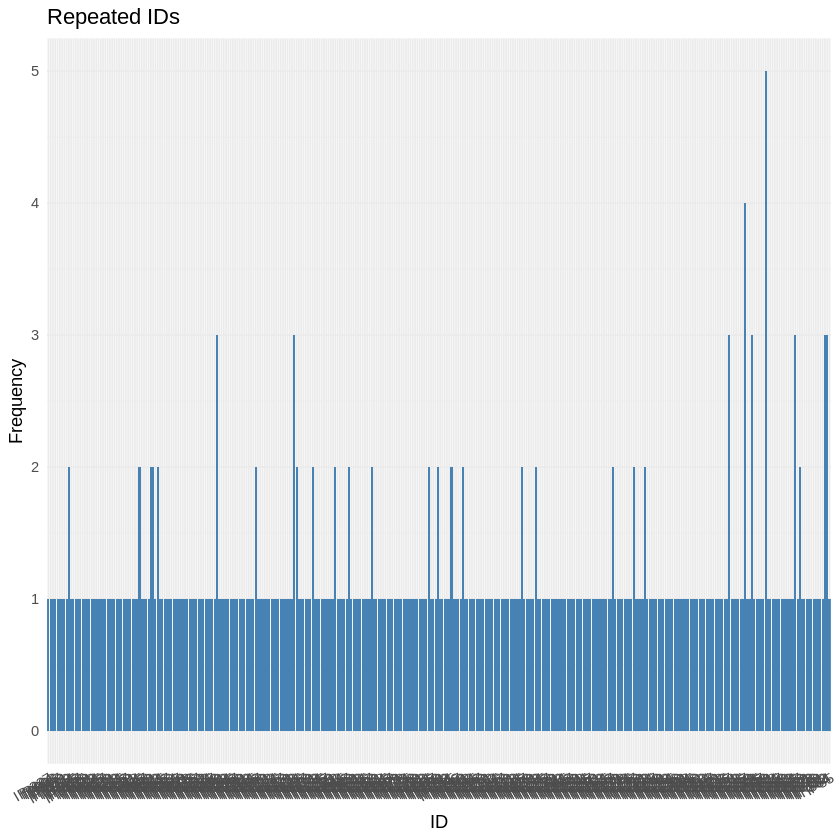

In [71]:
ggplot(idcounts_df , aes(x = ID, y = Count)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  theme_minimal() +
  labs(title = "Repeated IDs", x = "ID", y = "Frequency") +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

we pick out the repeating ones and bar graph them for a neater bar graph